# 07 · Water Dielectric Models (Behari 2005, Chapter 2)

Simulates and compares the dielectric models for free and bound water
from Chapter 2 of Behari (2005):

- **Debye equation** (Eq. 2.12–2.14): single relaxation time model
- **Cole-Cole equation** (Eq. 2.15): spread in relaxation times, most accurate
- **Klein & Swift** static dielectric constant (Eq. 2.17)
- **Stogryn** relaxation time (Eq. 2.18)
- Temperature dependence (Table 2.2)
- Bound vs free water comparison
- Reproduces **Fig. 2.6** and **Fig. 2.7** style plots (ε vs frequency for different textures/moisture)

---
**Reference**
- Behari, J. (2005). *Microwave Dielectric Behavior of Wet Soils*. Springer.
  ISBN 1-4020-3271-4. Chapter 2.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from navasar.behari import (
    debye_water, cole_cole_water, klein_swift_static,
    stogryn_relaxation
)
# Also import Hallikainen for comparison
from navasar.dielectric import hallikainen_dielectric

plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

## Klein & Swift static dielectric constant vs temperature

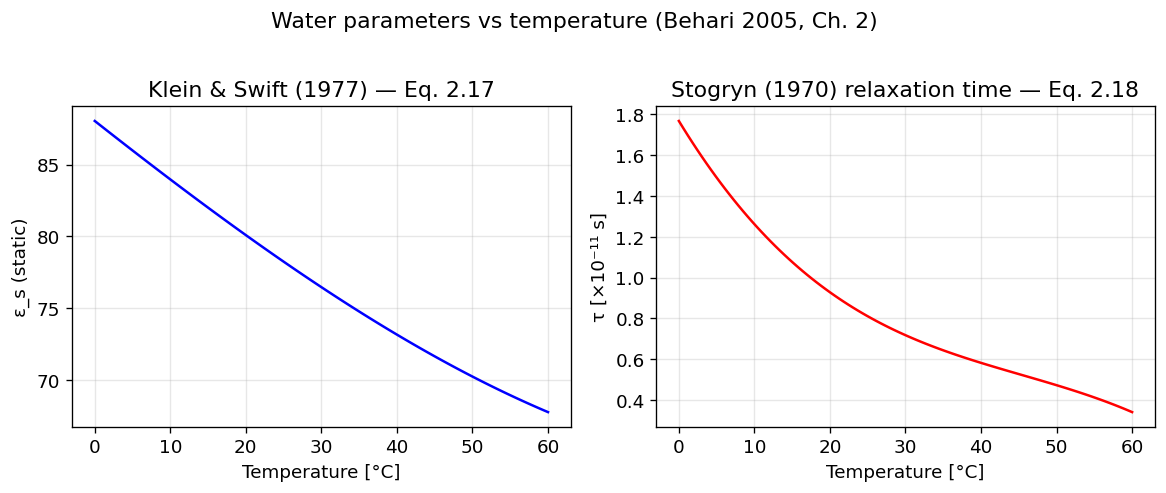

In [2]:
T_range = np.linspace(0, 60, 100)
eps_s = klein_swift_static(T_range)
tau   = stogryn_relaxation(T_range) * 1e11  # in units of 1e-11 s

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(T_range, eps_s, 'b')
axes[0].set_xlabel('Temperature [°C]')
axes[0].set_ylabel("ε_s (static)")
axes[0].set_title('Klein & Swift (1977) — Eq. 2.17')
axes[0].grid(True, alpha=0.3)

axes[1].plot(T_range, tau, 'r')
axes[1].set_xlabel('Temperature [°C]')
axes[1].set_ylabel('τ [×10⁻¹¹ s]')
axes[1].set_title('Stogryn (1970) relaxation time — Eq. 2.18')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Water parameters vs temperature (Behari 2005, Ch. 2)', y=1.02)
plt.tight_layout()
plt.savefig('../examples/fig_water_params_vs_T.png', dpi=150)
plt.show()

## Debye vs Cole-Cole: free water dielectric spectrum

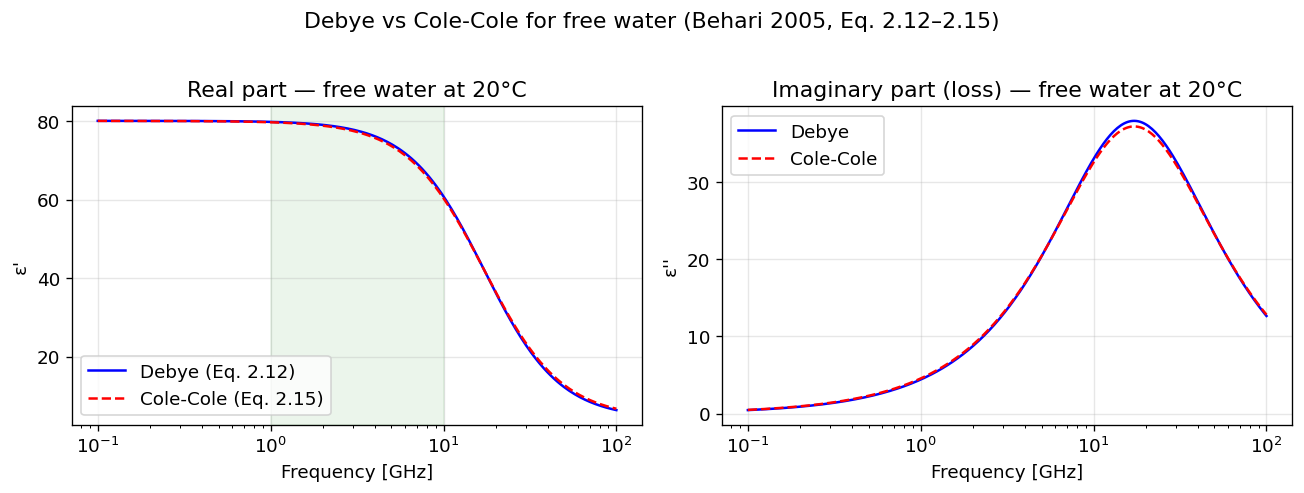

In [3]:
freq = np.logspace(-1, 2, 300)  # 0.1 to 100 GHz

eps_debye = debye_water(freq, T_celsius=20)
eps_cc    = cole_cole_water(freq, T_celsius=20, bound=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].semilogx(freq, eps_debye.real, 'b-',  label='Debye (Eq. 2.12)')
axes[0].semilogx(freq, eps_cc.real,    'r--', label='Cole-Cole (Eq. 2.15)')
axes[0].set_xlabel('Frequency [GHz]')
axes[0].set_ylabel("ε'")
axes[0].set_title('Real part — free water at 20°C')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].axvspan(1, 10, alpha=0.08, color='green', label='Microwave')

axes[1].semilogx(freq, eps_debye.imag, 'b-',  label='Debye')
axes[1].semilogx(freq, eps_cc.imag,    'r--', label='Cole-Cole')
axes[1].set_xlabel('Frequency [GHz]')
axes[1].set_ylabel("ε''")
axes[1].set_title('Imaginary part (loss) — free water at 20°C')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Debye vs Cole-Cole for free water (Behari 2005, Eq. 2.12–2.15)', y=1.02)
plt.tight_layout()
plt.savefig('../examples/fig_debye_vs_colecole.png', dpi=150)
plt.show()

## Free water vs bound water (Table 2.1)

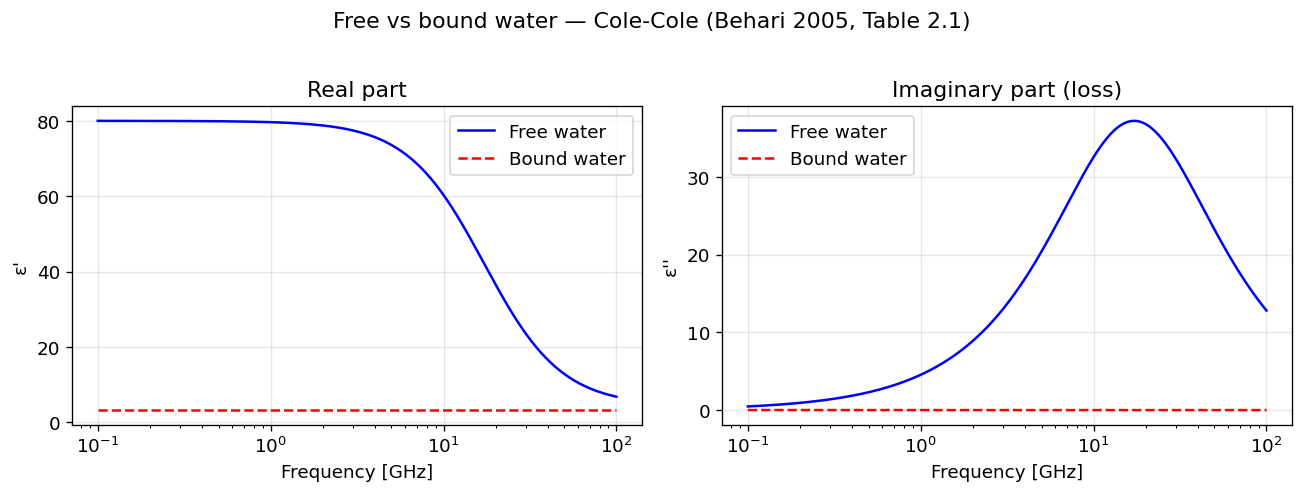

At 1.4 GHz:
  Free water:  ε = 79.4 + j6.31
  Bound water: ε = 3.2 + j0.0007
  Ratio ε_fw/ε_bw = 25.2x  (bound water behaves like ice)


In [4]:
eps_fw = cole_cole_water(freq, T_celsius=20, bound=False)
eps_bw = cole_cole_water(freq, T_celsius=20, bound=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].semilogx(freq, eps_fw.real, 'b-',  label='Free water')
axes[0].semilogx(freq, eps_bw.real, 'r--', label='Bound water')
axes[0].set_xlabel('Frequency [GHz]'); axes[0].set_ylabel("ε'")
axes[0].set_title('Real part'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].semilogx(freq, eps_fw.imag, 'b-',  label='Free water')
axes[1].semilogx(freq, eps_bw.imag, 'r--', label='Bound water')
axes[1].set_xlabel('Frequency [GHz]'); axes[1].set_ylabel("ε''")
axes[1].set_title('Imaginary part (loss)'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Free vs bound water — Cole-Cole (Behari 2005, Table 2.1)', y=1.02)
plt.tight_layout()
plt.savefig('../examples/fig_free_vs_bound_water.png', dpi=150)
plt.show()

print('At 1.4 GHz:')
fw14 = cole_cole_water(1.4, 20, bound=False)
bw14 = cole_cole_water(1.4, 20, bound=True)
print(f'  Free water:  ε = {fw14.real:.1f} + j{fw14.imag:.2f}')
print(f'  Bound water: ε = {bw14.real:.1f} + j{bw14.imag:.4f}')
print(f'  Ratio ε_fw/ε_bw = {fw14.real/bw14.real:.1f}x  (bound water behaves like ice)')

## Temperature dependence of free water (Fig. 2.6 style)

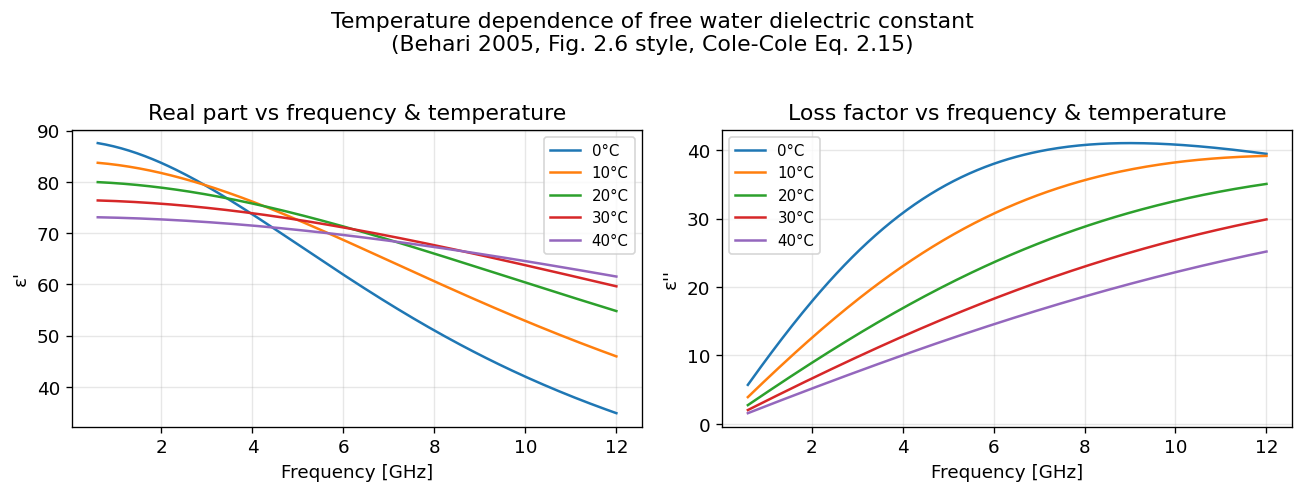

In [5]:
freq_mw = np.linspace(0.6, 12, 200)  # microwave range
temps = [0, 10, 20, 30, 40]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for T in temps:
    eps = cole_cole_water(freq_mw, T_celsius=T, bound=False)
    axes[0].plot(freq_mw, eps.real, label=f'{T}°C')
    axes[1].plot(freq_mw, eps.imag, label=f'{T}°C')

axes[0].set_xlabel('Frequency [GHz]'); axes[0].set_ylabel("ε'")
axes[0].set_title('Real part vs frequency & temperature')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Frequency [GHz]'); axes[1].set_ylabel("ε''")
axes[1].set_title('Loss factor vs frequency & temperature')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.suptitle('Temperature dependence of free water dielectric constant\n'
             '(Behari 2005, Fig. 2.6 style, Cole-Cole Eq. 2.15)', y=1.02)
plt.tight_layout()
plt.savefig('../examples/fig_water_temp_dependence.png', dpi=150)
plt.show()

## Saline Water Dielectric Properties (Klein & Swift 1977, Stogryn 1971)

Dissolved salts (salinity $S$) suppress the static dielectric constant $\varepsilon_s$ (Behari Eq. 2.19) and add an ionic conductivity term $\sigma / (\varepsilon_0 \omega)$ to the imaginary loss (Behari Eq. 2.21), which strongly dominates at lower frequencies like L-band (1.4 GHz).

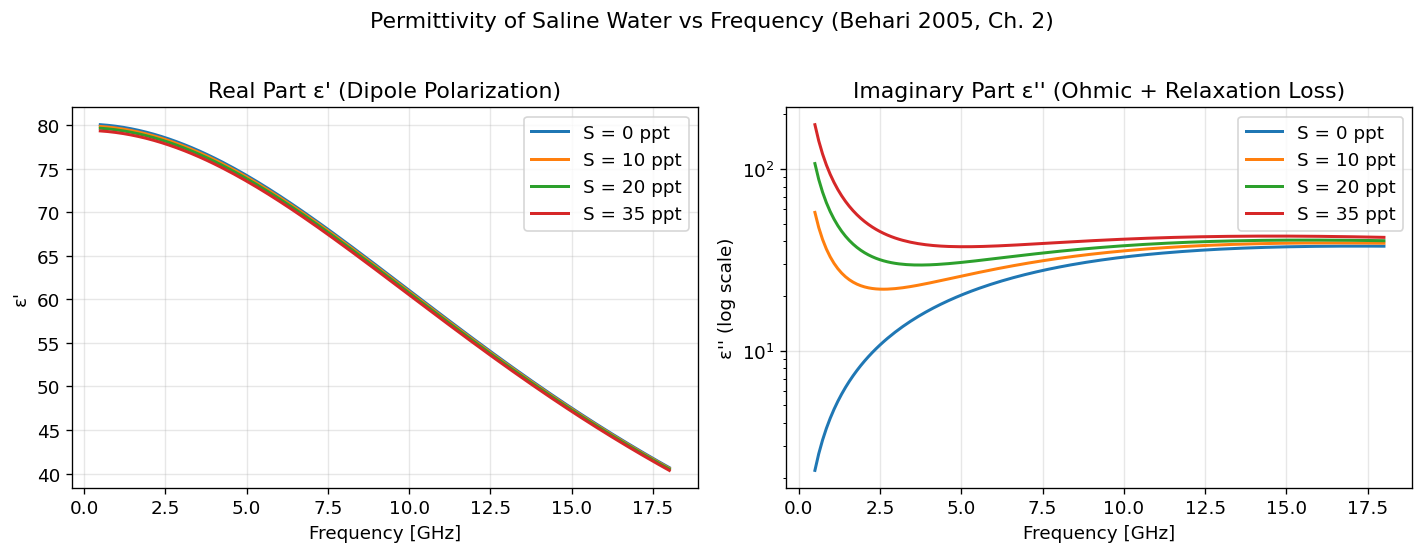

In [6]:
from navasar.behari import saline_water_dielectric

f_range = np.linspace(0.5, 18.0, 150)
salinities = [0.0, 10.0, 20.0, 35.0]  # ppt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
for S in salinities:
    eps_sal = saline_water_dielectric(f_range, T_celsius=20.0, salinity_ppt=S)
    ax1.plot(f_range, eps_sal.real, lw=1.8, label=f'S = {S:.0f} ppt')
    ax2.plot(f_range, eps_sal.imag, lw=1.8, label=f'S = {S:.0f} ppt')

ax1.set_xlabel('Frequency [GHz]'); ax1.set_ylabel("ε'")
ax1.set_title("Real Part ε' (Dipole Polarization)")
ax1.grid(True, alpha=0.3); ax1.legend()

ax2.set_xlabel('Frequency [GHz]'); ax2.set_ylabel("ε'' (log scale)")
ax2.set_title("Imaginary Part ε'' (Ohmic + Relaxation Loss)")
ax2.grid(True, alpha=0.3); ax2.set_yscale('log'); ax2.legend()

plt.suptitle('Permittivity of Saline Water vs Frequency (Behari 2005, Ch. 2)', y=1.02)
plt.tight_layout()
plt.savefig('../examples/fig_saline_water_dielectric.png', dpi=150)
plt.show()